# Mutational signatures and Relative timing of the clonal expansion

In [13]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pybedtools
import warnings; warnings.simplefilter('ignore')
from tqdm.notebook import tqdm

## Load sample dictionaries

In [3]:
sjd_dict = json.load(open('sample_ids/sample_sjd_ids.json','rb'))
tumors_dict = {'tumor1':'t1','tumor2':'t2'}

target_dict = json.load(open('sample_ids//sample_target_ids.json','rb'))
target_dict = {pt:target_dict[pt] for pt in target_dict.keys() if 'normal' in target_dict[pt].keys()}

stjude_dict = json.load(open('sample_ids/sample_stjude_ids.json','rb'))

pmc_dict = json.load(open('sample_ids/sample_pmc_ids.json','rb'))

samples_dict = sjd_dict | target_dict | stjude_dict | pmc_dict
pts = samples_dict.keys()

In [4]:
samples_final_ids_dict = json.load(open("sample_ids/sample_ids_final.json", "rb"))

In [5]:
samples2_dict = {samples_dict[pt][tumor]:tumor for pt in samples_dict.keys() for tumor in samples_dict[pt].keys() if tumor != 'sex'}
samples_list = [pt+'_t'+tumor[-1] for pt in samples_dict.keys() for tumor in samples_dict[pt].keys() if tumor not in ['normal','normal2','sex','clone1','clone2']]
samples_list = [pt if pt.startswith('pt') | pt.startswith('PMC') else pt.split('_t')[0] for pt in samples_list]
print(samples_list)

['pt1_t1', 'pt1_t2', 'pt3_t1', 'pt3_t2', 'pt4_t1', 'pt4_t2', 'pt5_t1', 'pt5_t2', 'pt6_t1', 'pt6_t2', 'pt7_t1', 'pt8_t1', 'pt9_t1', 'pt9_t2', 'pt11_t1', 'pt12_t1', 'pt12_t2', 'pt13_t1', 'pt14_t1', 'pt14_t2', 'pt15_t1', 'pt16_t1', 'pt17_t1', 'pt18_t1', 'pt18_t2', 'pt19_t1', 'pt20_t1', 'PABKLN', 'PADWRZ', 'PADYZI', 'PAEHIP', 'PAJLWM', 'PAJMBW', 'PAJMRB', 'PAJNER', 'PAJNFP', 'PAJNFZ', 'PAKHTL', 'PAKLYZ', 'PAKTCT', 'PARECB', 'PAREWI', 'PARGRN', 'PARIRN', 'PARPFY', 'PARRCL', 'PARTKH', 'PARUGK', 'PARZBI', 'PARZRH', 'PASABD', 'PASADZ', 'PASCDH', 'PASDLA', 'PASGCL', 'PASRHU', 'PASVDP', 'PASWZZ', 'PASXNA', 'PASYNF', 'PASZYE', 'PATAFT', 'PATBLF', 'PATDVL', 'PATENH', 'PATFXW', 'PATFZZ', 'PATXEE', 'PATXKA', 'PAUCGJ', 'PAUDPV', 'PAUEKW', 'PAUFVP', 'PAUGYZ', 'PAUHAZ', 'PAUNPA', 'PAVCKS', 'PAVITI', 'PAVYDM', 'PAVYKD', 'PAWDGA', 'PAWFBL', 'PAWFWK', 'SJ014754', 'SJ015723', 'SJ030128', 'SJ030255', 'SJ030581', 'SJ030707', 'SJ030896', 'SJ030997', 'SJ031235', 'SJ031605', 'SJ031948', 'SJ032047', 'SJ032346', 

In [6]:
purity_sjd_dict = json.load(open('purities/purities_sjd.json','rb'))
purity_target_dict = json.load(open('purities/purities_target.json','rb'))
purity_stjude_dict = json.load(open('purities/purities_stjude.json','rb'))
purity_pmc_dict = json.load(open('purities/purities_pmc_case.json','rb'))
purity_dict = purity_sjd_dict | purity_target_dict | purity_stjude_dict | purity_pmc_dict

## Prepare tables for input SigProfiler

Filter by gnomAD <0.001 to avoid possible germline contaminaton,\
Load mappable genome

In [8]:
mapp_genome_df = pd.read_csv('./mappable_genome/hg38_100bp.coverage.regions.filtered_blacklisted.gz',sep='\t')
mapp_genome_df

,CHR,START,END
0,chr1,800910,800916
1,chr1,802489,802502
2,chr1,811249,811276
3,chr1,817177,817381
4,chr1,818744,818840
...,...,...,...
886926,chrY,26635237,26635834
886927,chrY,26635942,26636036
886928,chrY,26636383,26636592
886929,chrY,26636850,26637108


In [9]:
def prepare_muts (df,mapp_genome_df=pd.DataFrame(),clonality=None):
    df = df[df['mut_type']=='snv']
    if clonality == 'clonal':
        df = df[df['clonal']==True]
    elif clonality == 'subclonal':
        df = df[df['clonal']==False]
    print(len(df),'mutations intersect')
    df = df[df['gnomADg_AF']<0.001]
    print(len(df), 'mutations after filtering gnomAD SNPs >0.001')

    #filter out mutations from low mappability regions with pybedtools intersect with the mappable genome
    df['POS2'] = df['POS'] + 1
    df = df[['#CHROM','POS','POS2','REF','ALT','FILTER']]
    if len(mapp_genome_df) != 0:
        mappgen_bt = pybedtools.BedTool.from_dataframe(mapp_genome_df)
        snvs_bt = pybedtools.BedTool.from_dataframe(df)
        mappgen_and_snvs = snvs_bt.intersect(mappgen_bt)
        snvs_mappgen_df = mappgen_and_snvs.to_dataframe()
        if len(snvs_mappgen_df) == 0:
            snvs_mappgen_df = pd.DataFrame(columns=['#CHROM','POS','FILTER','REF','ALT'])
        else:
            snvs_mappgen_df = snvs_mappgen_df.rename(columns={'chrom':'#CHROM','start':'POS','end':'POS2',
                                                             'name':'REF','score':'ALT','strand':'FILTER'})
            snvs_mappgen_df = snvs_mappgen_df.drop(columns=['POS2'])

        print(len(snvs_mappgen_df), 'mutations after filtering regions with low mappability')
        df_out = snvs_mappgen_df.copy()
    else:
        df_out = df.copy()
    
    return df_out

In [10]:
path = './signature_analysis/sigprofiler/extraction/analysis/'
if os.path.exists(path) == False:
    os.mkdir(path)

for subset in ['allmuts','clonal','subclonal']:
    if os.path.exists(path+subset+'/') == False:
        os.mkdir(path+subset+'/')
    if os.path.exists(path+subset+'/input/') == False:
        os.mkdir(path+subset+'/input/')

In [12]:
#replace path to your 'rhabdoids' conda env path
pybedtools.helpers.set_bedtools_path('/home/msanchezg/miniconda3/envs/rhabdoids/bin/')

!!! This code takes ~10-15 min to execute !!!  
It has already been run, do not need to execute it again!

In [14]:
cols = ['#CHROM','POS','FILTER','REF','ALT']
for pt in tqdm(pts):
    for t in [sample for sample in samples_dict[pt].keys() if sample not in ['sex','normal','normal2']]:
        print(pt)
        normal_id = samples_dict[pt]['normal']
        tumor_id = samples_dict[pt][t]
        sample_id = tumor_id + '_vs_'+normal_id
        if pt.startswith('pt'):
            cohort = 'sjd'
        elif pt.startswith('PA'):
            cohort = 'target'
        elif pt.startswith('PMC'):
            cohort = 'pmc'
        else:
            cohort = 'stjude'
        df = pd.read_csv('/data/bbg/projects/rhabdoid_tumors/mafs_'+cohort+'/'+pt+'/'+sample_id+'/filter_and_annot/'+sample_id+'_filt.maf.gz',sep='\t')
        for subset in ['allmuts','clonal','subclonal']:
            snvs_mappgen_df = prepare_muts (df,mapp_genome_df,clonality=subset)
            snvs_mappgen_df[cols].to_csv('./signature_analysis/sigprofiler/extraction/analysis/'+subset+'/'+sample_id+'.vcf',sep='\t',index=None)

  0%|          | 0/95 [00:00<?, ?it/s]

pt1
3194 mutations intersect
2259 mutations after filtering gnomAD SNPs >0.001
1914 mutations after filtering regions with low mappability
1930 mutations intersect
1786 mutations after filtering gnomAD SNPs >0.001
1553 mutations after filtering regions with low mappability
1264 mutations intersect
473 mutations after filtering gnomAD SNPs >0.001
361 mutations after filtering regions with low mappability
pt1
2186 mutations intersect
2048 mutations after filtering gnomAD SNPs >0.001
1785 mutations after filtering regions with low mappability
1838 mutations intersect
1729 mutations after filtering gnomAD SNPs >0.001
1514 mutations after filtering regions with low mappability
348 mutations intersect
319 mutations after filtering gnomAD SNPs >0.001
271 mutations after filtering regions with low mappability
pt3
1974 mutations intersect
1190 mutations after filtering gnomAD SNPs >0.001
956 mutations after filtering regions with low mappability
1012 mutations intersect
838 mutations after filt

## Create TAB dictionaries

In [6]:
tab_sjd_dict = {'pt1_t1':8.32,
                'pt1_t2':8.56,
                'pt3_t1':4.79,
                'pt3_t2':6.16,
                'pt4_t1':0.02,
                'pt4_t2':0.03,
                'pt5_t1':13.5,
                'pt5_t2':13.7,
                'pt6_t1':1.60,
                'pt6_t2':1.64,
                'pt7_t1':2.25,
                'pt8_t1':3.02,
                'pt9_t1':0.44,
                'pt9_t2':0.49,
                'pt11_t1':5.57,
                'pt12_t1':0.68,
                'pt12_t2':0.68,
                'pt13_t1':0.53,
                'pt14_t1':10.10,
                'pt14_t2':10.50,
                'pt15_t1':15.58,
                'pt16_t1':1.67,
                'pt17_t1':2.61,
                'pt18_t1':0.01,
                'pt18_t2':0.02,
                'pt19_t1':1.13,
                'pt20_t1':0.57}

tab_pmc_dict = {'PMC01_t1':2.5,
            'PMC01_t2':2.5,
            'PMC01_t3':2.5,
            'PMC01_t4':2.5}

In [8]:
clinical_df = pd.read_csv('clinical_data/target_parsed_clinical_info.tsv',sep='\t')
clinical_df[['patient','age_at_diagnosis']]
clinical_df['age_at_diagnosis_years'] = round(clinical_df['age_at_diagnosis'] / 365,2)
tab_target_dict = dict(zip(clinical_df['patient'],clinical_df['age_at_diagnosis_years']))

clinical_df = pd.read_csv('clinical_data/StJude_clinical_data.txt',sep='\t')
clinical_df = clinical_df[['subject_name','attr_age_at_diagnosis']].drop_duplicates()
clinical_df = clinical_df[clinical_df['attr_age_at_diagnosis']!='Not Available'].drop_duplicates('subject_name')
clinical_df['attr_age_at_diagnosis'] = clinical_df['attr_age_at_diagnosis'].astype(float)
tab_stjude_dict = dict(zip(clinical_df['subject_name'],clinical_df['attr_age_at_diagnosis']))

tab_dict = tab_sjd_dict | tab_target_dict | tab_stjude_dict | tab_pmc_dict
tab_dict

{'pt1_t1': 8.32,
 'pt1_t2': 8.56,
 'pt3_t1': 4.79,
 'pt3_t2': 6.16,
 'pt4_t1': 0.02,
 'pt4_t2': 0.03,
 'pt5_t1': 13.5,
 'pt5_t2': 13.7,
 'pt6_t1': 1.6,
 'pt6_t2': 1.64,
 'pt7_t1': 2.25,
 'pt8_t1': 3.02,
 'pt9_t1': 0.44,
 'pt9_t2': 0.49,
 'pt11_t1': 5.57,
 'pt12_t1': 0.68,
 'pt12_t2': 0.68,
 'pt13_t1': 0.53,
 'pt14_t1': 10.1,
 'pt14_t2': 10.5,
 'pt15_t1': 15.58,
 'pt16_t1': 1.67,
 'pt17_t1': 2.61,
 'pt18_t1': 0.01,
 'pt18_t2': 0.02,
 'pt19_t1': 1.13,
 'pt20_t1': 0.57,
 'PABKLN': 1.1,
 'PADWRZ': 1.05,
 'PADYCE': 2.28,
 'PADYZI': 2.97,
 'PAEHIP': 0.48,
 'PAJLRA': 0.01,
 'PAJLWM': 0.79,
 'PAJMBW': 0.39,
 'PAJMRB': 1.48,
 'PAJNER': 0.17,
 'PAJNFP': 0.96,
 'PAJNFZ': 1.62,
 'PAJPHJ': 0.95,
 'PAKHTL': 3.13,
 'PAKLYZ': 1.44,
 'PAKPEW': 2.6,
 'PAKTCT': 2.36,
 'PARECB': 0.38,
 'PAREWI': 0.84,
 'PARGRN': 0.4,
 'PARIRN': 4.02,
 'PARKKN': 6.45,
 'PARPFY': 0.99,
 'PARRCL': 0.59,
 'PARTKH': 0.73,
 'PARUGK': 0.6,
 'PARZBI': 1.44,
 'PARZRH': 1.67,
 'PASABD': 0.47,
 'PASADZ': 0.75,
 'PASAMZ': 8.29,
 'PAS

In [9]:
with open('clinical_data/tab_dict.json','w') as f:
    json.dump(tab_dict,f)

## Timing clonal expansion from aging signatures

In [10]:
ttmt_dict = {'AX4912':'naive',
            'AX4914':'naive',
            'AX4915':'StJude',
            'AX4916':'naive',
            'AX4918':'naive',
            'AX4944':'StJude',
            'AX4945':'Boston',
            'AX4921':'Boston',
            'AX4922':'COG',
            'AX4930':'naive',
            'AX4924':'naive',
            'AX4925':'mP6',
            'AX4926':'mP6',
            'AX4927':'EU-RHAB',
            'AX4928':'MSKCC',
            'AX4929':'MSKCC',
            'AX4923':'ifo/doxo/radio',
            'AX4931':'naive',
            'AX4932':'naive',
            'AX4933':'naive',
            'AX4934':'naive',
            'AX4935':'ttmt unknown',
            'AX4936':'naive',
            'AX4937':'mP6',
            'AX4938':'naive',
            'AX4951':'naive',
            'AX4940':'mP6',
            'OMEN':'ifo/doxo/etop/vincr',
            'LN':'ifo/doxo/etop/vincr',
            'LNMETA':'ifo/doxo/etop/vincr',
            'DIAF':'ifo/doxo/etop/vincr'}

In [11]:
ttmt2_dict = {}

for pt in samples_dict.keys():
	tumors = [t for t in samples_dict[pt].keys() if 'tumor' in t]
	for t in tumors:
		if pt.startswith('pt') | pt.startswith('PMC'):
			sample_id = pt + '_t' + t[-1]
			tumor_id = samples_dict[pt][t]
			ttmt2_dict[sample_id] = ttmt_dict[tumor_id]
		elif pt.startswith('PA'):
			sample_id = pt
			ttmt2_dict[sample_id] = 'naive'
		elif pt.startswith('SJ'):
			sample_id = pt
			ttmt2_dict[sample_id] = 'NA'

ttmt2_dict

{'pt1_t1': 'naive',
 'pt1_t2': 'mP6',
 'pt3_t1': 'naive',
 'pt3_t2': 'StJude',
 'pt4_t1': 'naive',
 'pt4_t2': 'naive',
 'pt5_t1': 'naive',
 'pt5_t2': 'StJude',
 'pt6_t1': 'Boston',
 'pt6_t2': 'Boston',
 'pt7_t1': 'COG',
 'pt8_t1': 'naive',
 'pt9_t1': 'naive',
 'pt9_t2': 'mP6',
 'pt11_t1': 'naive',
 'pt12_t1': 'mP6',
 'pt12_t2': 'mP6',
 'pt13_t1': 'EU-RHAB',
 'pt14_t1': 'MSKCC',
 'pt14_t2': 'MSKCC',
 'pt15_t1': 'ifo/doxo/radio',
 'pt16_t1': 'naive',
 'pt17_t1': 'naive',
 'pt18_t1': 'naive',
 'pt18_t2': 'naive',
 'pt19_t1': 'ttmt unknown',
 'pt20_t1': 'naive',
 'PABKLN': 'naive',
 'PADWRZ': 'naive',
 'PADYZI': 'naive',
 'PAEHIP': 'naive',
 'PAJLWM': 'naive',
 'PAJMBW': 'naive',
 'PAJMRB': 'naive',
 'PAJNER': 'naive',
 'PAJNFP': 'naive',
 'PAJNFZ': 'naive',
 'PAKHTL': 'naive',
 'PAKLYZ': 'naive',
 'PAKTCT': 'naive',
 'PARECB': 'naive',
 'PAREWI': 'naive',
 'PARGRN': 'naive',
 'PARIRN': 'naive',
 'PARPFY': 'naive',
 'PARRCL': 'naive',
 'PARTKH': 'naive',
 'PARUGK': 'naive',
 'PARZBI': 'nai

In [12]:
with open('clinical_data/ttmt_dict.json','w') as f:
    json.dump(ttmt2_dict,f)

In [13]:
def change_name (sample,samples_dict,samples2_dict):
    tumor_id = sample.split('_vs_')[0]
    normal_id = sample.split('_vs_')[1]
    pt = [ pt for pt in samples_dict.keys() if samples_dict[pt]['normal']==normal_id]
    pt = pt[0]
    t = samples2_dict[tumor_id]
    if pt.startswith('pt') | pt.startswith('PMC'):
        sample2 = pt +'_'+t[0]+t[-1]
    else:
        sample2 = pt
    return sample2


def color_sigs (sigs):

    colors_dict = {}
    colors_list = []
    i = 0
    for sig in sigs:
        if 'potential' in sig:
            color = greys[i]
            i+=1
        elif sig in sbs_color_dict.keys():
            color = sbs_color_dict[sig]
        else:
            color = greys[i]
            i+=1
            pass
        colors_dict[sig] = color
        colors_list.append(color)
    return colors_dict,colors_list

sbs_color_dict = {'SBS1':'orange',
                 'SBS2':'olive',
                 'SBS3':'mediumpurple',
                 'SBS5':'skyblue',
                 'SBS7a':'teal',
                 'SBS8':'goldenrod',
                 'SBS18':'royalblue',
                 'SBS12':'seagreen',
                 'SBS13':'purple',
                 'SBS17a':'green',
                 'SBS17b':'forestgreen',
                 'SBS31':'firebrick',
                 'SBS32':'plum',
                 'SBS35':'lightcoral',
                 'SBS40b':'turquoise',
                 'SBS45':'steelblue',
                 'SBS60':'darkseagreen',
                 'SBS84':'moccasin',
                 'SBS90':'plum'}
greys = ['gainsboro','lightgrey','lightgray','silver','darkgrey','darkgray','grey','gray','dimgrey','dimgray','slategrey']


In [14]:
import numpy as np
import seaborn as sns
from numpy.polynomial.polynomial import polyfit
from scipy import stats
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

## All mutations (clonal + subclonal)

In [15]:
def set_cohort (sample):
    if sample.startswith('pt'):
        cohort = 'SJD'
    elif sample.startswith('PA'):
        cohort = 'TARGET'
    elif sample.startswith('SJ'):
        cohort = 'StJude'
    elif sample.startswith('PMC'):
        cohort = 'PMC'
    return cohort

In [19]:
def prepare_df (subset):
	df1 = pd.read_csv('signature_analysis/sigprofiler/extraction/analysis/'+subset+'/results/SBS96/Suggested_Solution/COSMIC_SBS96_Decomposed_Solution/Activities/COSMIC_SBS96_Activities.txt',sep='\t')
	df1['Samples2'] = df1['Samples'].apply(lambda x: change_name(x,samples_dict,samples2_dict))
	df1.index = df1['Samples2']
	df1 = df1.reindex(samples_list)
	df1['ttmt'] = df1.index.map(ttmt2_dict)
	df1.drop(['Samples','Samples2'],inplace=True,axis=1)

	excluded_sjd_samples = ['pt2_t1','pt9_t1','pt10_t1','pt14_t2','pt16_t1','pt20_t1']
	bad_quality_samples = ['SJ032047','SJ033133']
	xenograft = ['SJ063832']
	no_age_data = ['SJ014754']
	neuroblastoma = ['PAKLYZ']
	excluded_samples =  excluded_sjd_samples + bad_quality_samples + xenograft+ no_age_data + neuroblastoma

	df1 = df1[~df1.index.isin(excluded_samples)]
	# cols = [col for col in df1.columns if col not in ['SBS46','SBS57','SBS90']]
	cols = df1.columns
	df1 = df1[cols]
	# add age info
	col_sigs = [col for col in df1.columns if 'SBS' in col]
	df1['total'] = df1[col_sigs].sum(axis=1)
	df1['age'] = df1.index.map(tab_dict)

	#remove samples without age info
	df1 = df1[~df1['age'].isnull()]
	df1 = df1.sort_values('age',ascending=True)
	df1 = df1.drop(['total'],axis=1)
	df1[col_sigs] = df1[col_sigs].fillna(0)
 
 	#add cohort info
	df1['COHORT'] = df1.index.map(set_cohort)
	return df1

In [50]:
def prepare_df_from_refitting (subset):
	df1 = pd.DataFrame()
	for sample in samples_list:
		df = pd.read_csv('signature_analysis/sigprofiler/fitting/results/'+sample+'/'+subset+'/Assignment_Solution/Activities/Assignment_Solution_Activities.txt',sep='\t')
		df1 = pd.concat([df1,df],ignore_index=True)
	cosmic_sigs = pd.read_csv('signature_analysis/COSMIC_v3.4_SBS_GRCh38.txt',sep='\t')
	cosmic_sigs = cosmic_sigs.columns
	cosmic_sigs = list(cosmic_sigs.drop('Type'))

	sigs_col = sorted([s for s in df1.columns if s.startswith('SBS')],key=lambda x: cosmic_sigs.index(x))
	df1 = df1[['Samples']+sigs_col]
	df1.index = df1['Samples']
	df1 = df1.reindex(samples_list)
	df1['ttmt'] = df1.index.map(ttmt2_dict)
	df1.drop(['Samples'],inplace=True,axis=1)

	excluded_sjd_samples = ['pt2_t1','pt9_t1','pt10_t1','pt14_t2','pt16_t1','pt20_t1']
	bad_quality_samples = ['SJ032047','SJ033133']
	xenograft = ['SJ063832']
	no_age_data = ['SJ014754']
	neuroblastoma = ['PAKLYZ']
	excluded_samples =  excluded_sjd_samples + bad_quality_samples + xenograft+ no_age_data + neuroblastoma

	df1 = df1[~df1.index.isin(excluded_samples)]
	# cols = [col for col in df1.columns if col not in ['SBS46','SBS57','SBS90']]
	cols = df1.columns
	df1 = df1[cols]
	# add age info
	col_sigs = [col for col in df1.columns if 'SBS' in col]
	df1['total'] = df1[col_sigs].sum(axis=1)
	df1['age'] = df1.index.map(tab_dict)

	#remove samples without age info
	df1 = df1[~df1['age'].isnull()]
	df1 = df1.sort_values('age',ascending=True)
	df1 = df1.drop(['total'],axis=1)
	df1[col_sigs] = df1[col_sigs].fillna(0)
 
	#add cohort info
	df1['COHORT'] = df1.index.map(set_cohort)
 
	return df1

In [20]:
allmuts_df = prepare_df('allmuts')

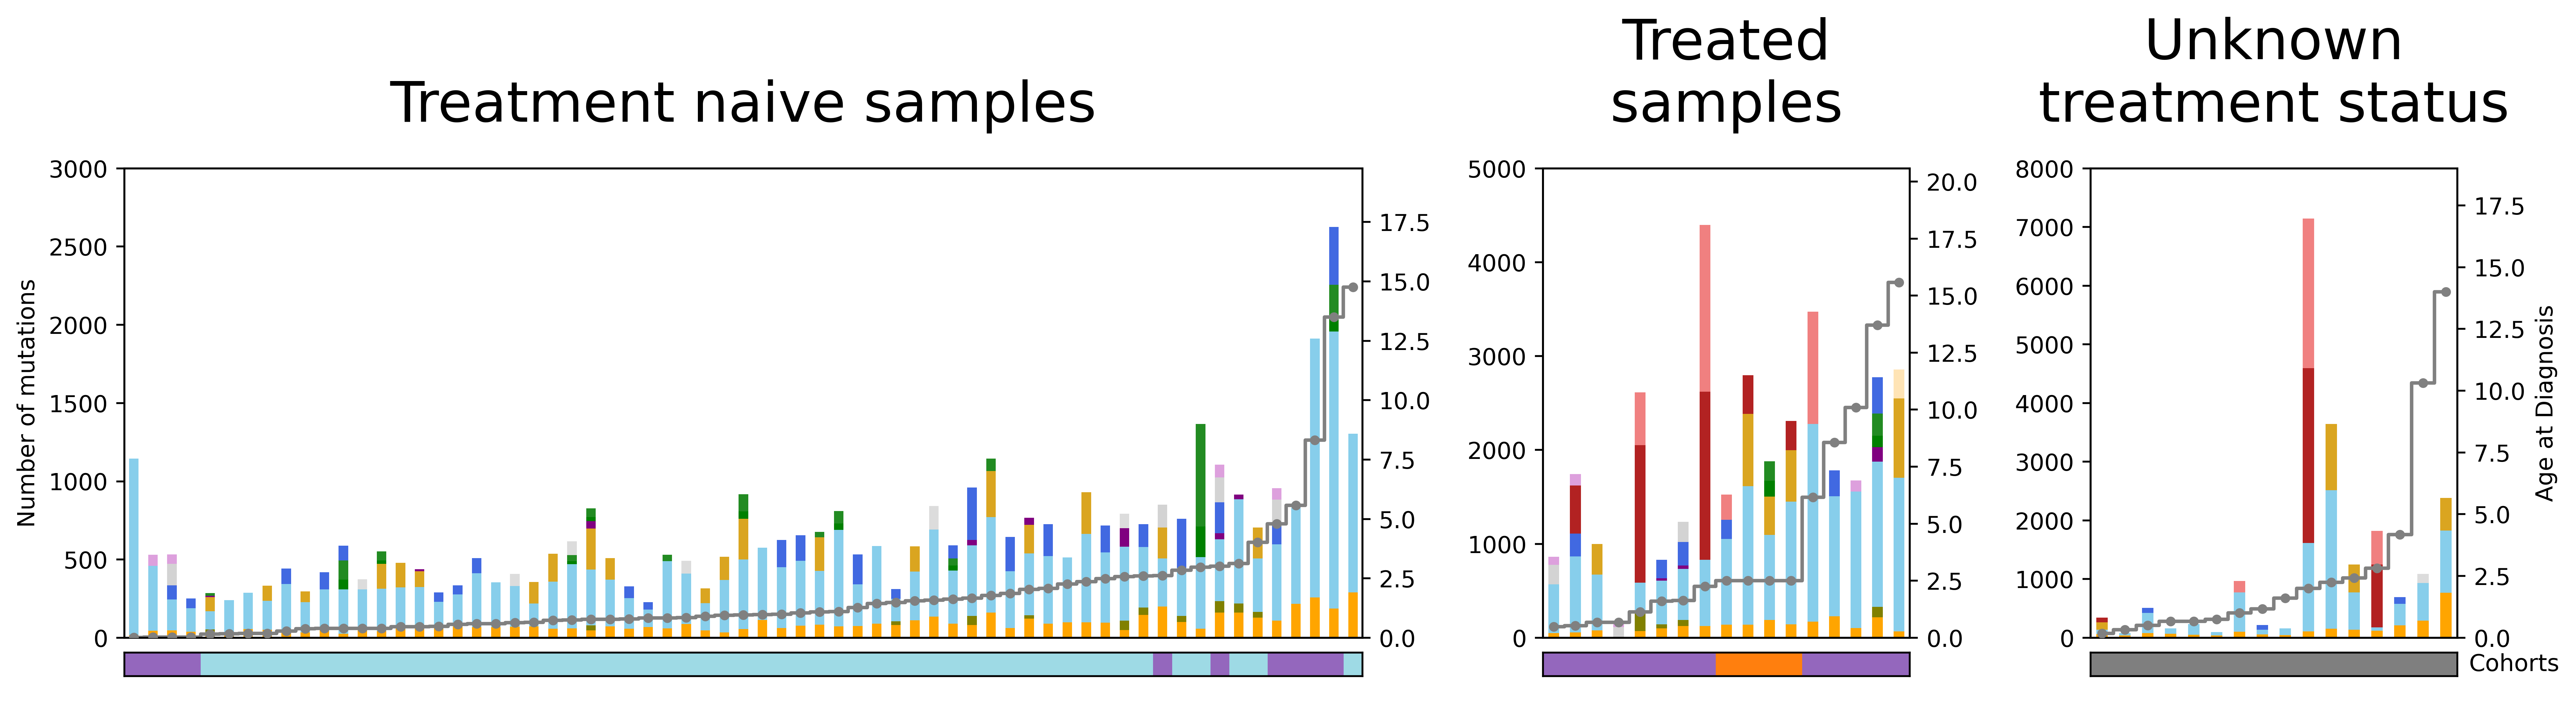

In [22]:
fig = plt.figure(figsize=(4,16), dpi=500)
gs = gridspec.GridSpec(2, 4, height_ratios=[4,0.2], width_ratios=[13.5,4,4,1], hspace=0.06, wspace=0.35)

ax0 = fig.add_subplot(gs[0,0])

col_sigs = [col for col in allmuts_df.columns if 'SBS' in col]
colors_dict,colors_list = color_sigs(col_sigs)
df1 = allmuts_df[allmuts_df['ttmt'].isin(['naive'])]
df1[col_sigs].plot.bar(ax=ax0,stacked=True,figsize=(20,4),color=colors_list,legend=False)
ax0.set_title('Treatment naive samples',size=24,pad=20)
ax0.set_ylim([0,3000])
ax0.set_xlabel('')
ax0.set_xticks([])
ax0.set_ylabel('Number of mutations')

ax1 = fig.add_subplot(gs[0,1])

df2 = allmuts_df[~allmuts_df['ttmt'].isin(['naive','NA'])]
df2[col_sigs].plot.bar(ax=ax1,stacked=True,figsize=(20,4),color=colors_list,legend=False)
ax1.set_title('Treated\nsamples',size=24,pad=20)
ax1.set_ylim([0,5000])
ax1.set_xlabel('')
ax1.set_xticks([])

ax2 = fig.add_subplot(gs[0,2])

df3 = allmuts_df[allmuts_df['ttmt'].isin(['NA'])]
df3[col_sigs].plot.bar(ax=ax2,stacked=True,figsize=(20,4),color=colors_list,legend=False)
ax2.set_title('Unknown\ntreatment status',size=24,pad=20)
ax2.set_ylim([0,8000])
ax2.set_xlabel('')
ax2.set_xticks([])

# Function to add the age layer
def add_age_track(ax, df, color='black'):
    # Create a twin axis that shares the same x-axis
    ax_age = ax.twinx()
    
    # Plot age. Using a step or line plot. 
    ax_age.step(range(len(df)), df['age'], color=color, where='mid', linewidth=1.5)
    
    # Optional: Add points to make specific sample ages clearer
    ax_age.scatter(range(len(df)), df['age'], color=color, s=10, zorder=3)
    
    # Set labels and limits
    ax_age.set_ylim(0, df['age'].max() + 5) # Buffer for visibility
    return ax_age

# Apply to your subplots
ax0_age = add_age_track(ax0, df1, color='grey')
ax1_age = add_age_track(ax1, df2, color='grey')
ax2_age = add_age_track(ax2, df3, color='grey')
ax2_age.set_ylabel('Age at Diagnosis') # Only label the first or last one to save space

# --- Heatmap ---

# 1. Setup Global Mapping
all_cohorts = sorted(allmuts_df['COHORT'].unique().tolist())
cohort_to_idx = {name: i for i, name in enumerate(all_cohorts)}
n_cohorts = len(all_cohorts)

# Get the specific colormap
colormap_dict = {'COHORT': 'tab20'}
feature_colormaps = {}
n_cats = len(all_cohorts)
cmap_name = colormap_dict.get('COHORT', 'Spectral')
cmap = plt.get_cmap(cmap_name)
colors = cmap(np.linspace(0.1, 1, n_cats))
feature_colormaps['COHORT'] = ListedColormap(colors)
current_cmap = feature_colormaps['COHORT']

# 2. Define the NORM once (remove the redundant/broken one inside the loop)
boundaries = np.arange(n_cohorts + 1) - 0.5
norm = mcolors.BoundaryNorm(boundaries=boundaries, ncolors=n_cohorts)

n=0
for df in [df1,df2,df3]:
    ax01 = fig.add_subplot(gs[1,n])

    data = df['COHORT'].map(cohort_to_idx).values

    # Plot the column as an individual image on the same axes
    im = ax01.imshow(data[np.newaxis, :], aspect='auto', cmap=current_cmap, norm=norm)
    n=n+1
    
    # Cleaning up axes
    ax01.set_xticks([])
    ax01.set_yticks([])
    
ax01.text(x=len(data),y=0,s='Cohorts',va='center')
plt.savefig('plots/mutational_signatures_all_samples.svg', bbox_inches='tight',format='svg')

[<matplotlib.lines.Line2D object at 0x147194c0b730>, <matplotlib.lines.Line2D object at 0x147194c66e30>]
[<matplotlib.lines.Line2D object at 0x147194c95990>, <matplotlib.lines.Line2D object at 0x147194c96830>]
[<matplotlib.lines.Line2D object at 0x147194c96b30>, <matplotlib.lines.Line2D object at 0x147194c97af0>, <matplotlib.lines.Line2D object at 0x147194c97be0>, <matplotlib.lines.Line2D object at 0x147194c97cd0>, <matplotlib.lines.Line2D object at 0x147194c97dc0>, <matplotlib.lines.Line2D object at 0x147194c97eb0>, <matplotlib.lines.Line2D object at 0x147194c97fa0>, <matplotlib.lines.Line2D object at 0x147194cb00d0>, <matplotlib.lines.Line2D object at 0x147194cb01c0>, <matplotlib.lines.Line2D object at 0x147194cb02b0>, <matplotlib.lines.Line2D object at 0x147194cb03a0>]


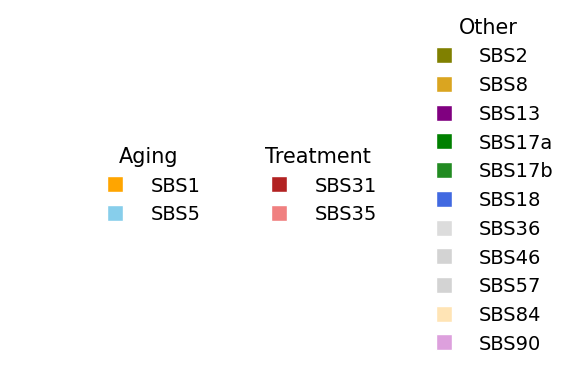

In [23]:
categories_dict = {'Aging' : ['SBS1','SBS5'],
                   'Treatment' : ['SBS31','SBS35'],
                   'Other' : [sig for sig in colors_dict.keys() if sig not in ['SBS1','SBS5','SBS31','SBS35']]}

legend_fig, legend_axs = plt.subplots(1, len(categories_dict.keys()), figsize=(6, 1), dpi=100, gridspec_kw={'width_ratios': [1,1,1]})

idx = 0

for category in categories_dict.keys():
    sigs = categories_dict[category]
    n_cats = len(sigs)
    labels = sigs
    colors_list = [colors_dict[sig] for sig in sigs]
    handles = [plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=colors_list[j], markersize=12) for j in range(n_cats)]
    print(handles)
    legend_axs[idx].axis('off')
    legend_title = category
    legend_axs[idx].legend(handles, labels, title=legend_title, loc='center left', bbox_to_anchor=(0.5, 0.5), ncol=1, fontsize=14, title_fontsize=15, frameon=False)
    idx += 1
plt.savefig('plots/mutational_signatures_all_samples_legend.svg', bbox_inches='tight',format='svg')

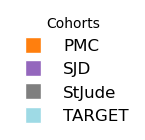

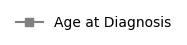

In [25]:
# --- Add Legend ---
## COHORT legend
# We create proxy artists for the legend based on your colormap
legend_handles = [
    mpatches.Patch(color=current_cmap(i), label=cohort) 
    for cohort, i in cohort_to_idx.items()
]
legend_handles = [
    Line2D([0], [0], marker='s', color='w', 
           markerfacecolor=current_cmap(i), markersize=12, label=cohort) 
    for cohort, i in cohort_to_idx.items()
]

plt.figure(figsize=(0,0),dpi=100)
plt.axis('off')
plt.legend(handles=legend_handles, title="Cohorts",fontsize=12, frameon=False)
plt.savefig('plots/cohorts_legend.svg', bbox_inches='tight',format='svg')
plt.show()

## Age legend

# Create a proxy for the age track
age_line = Line2D([0], [0], color='grey', marker='s', linestyle='-', 
                  markersize=6, label='Age at Diagnosis')

plt.figure(figsize=(0,0),dpi=100)
plt.axis('off')
plt.legend(handles=[age_line], loc='upper left', frameon=False, 
           facecolor='white', framealpha=0.8, fontsize=10)
plt.savefig('plots/age_at_diagnosis_legend.svg', bbox_inches='tight',format='svg')

In [26]:
print(len(allmuts_df[allmuts_df['COHORT']=='SJD']))
allmuts_df[allmuts_df['COHORT']=='SJD']

23


,SBS1,SBS2,SBS5,SBS8,SBS13,SBS17a,SBS17b,SBS18,SBS31,SBS35,SBS36,SBS46,SBS57,SBS84,SBS90,ttmt,age,COHORT
Samples2,,,,,,,,,,,,,,,,,,
pt18_t1,16,0,1130,0,0,0,0,0,0,0,0,0,0,0,0,naive,0.01,SJD
pt18_t2,45,0,415,0,0,0,0,0,0,0,0,0,0,0,71,naive,0.02,SJD
pt4_t1,46,0,199,0,0,0,0,90,0,0,0,0,137,0,61,naive,0.02,SJD
pt4_t2,38,0,150,0,0,0,0,63,0,0,0,0,0,0,0,naive,0.03,SJD
pt9_t2,49,0,519,0,0,0,0,0,0,0,0,0,208,0,87,mP6,0.49,SJD
pt13_t1,57,0,810,0,0,0,0,243,513,0,0,0,0,0,122,EU-RHAB,0.53,SJD
pt12_t2,78,0,595,327,0,0,0,0,0,0,0,0,0,0,0,mP6,0.68,SJD
pt12_t1,2,0,3,0,0,0,0,0,0,0,0,0,110,0,66,mP6,0.68,SJD
pt19_t1,72,189,325,0,0,0,0,0,1465,562,0,0,0,0,0,ttmt unknown,1.13,SJD


In [29]:
subset = 'clonal'
clonals_df = prepare_df_from_refitting(subset)
subset = 'subclonal'
subclonals_df = prepare_df_from_refitting(subset)

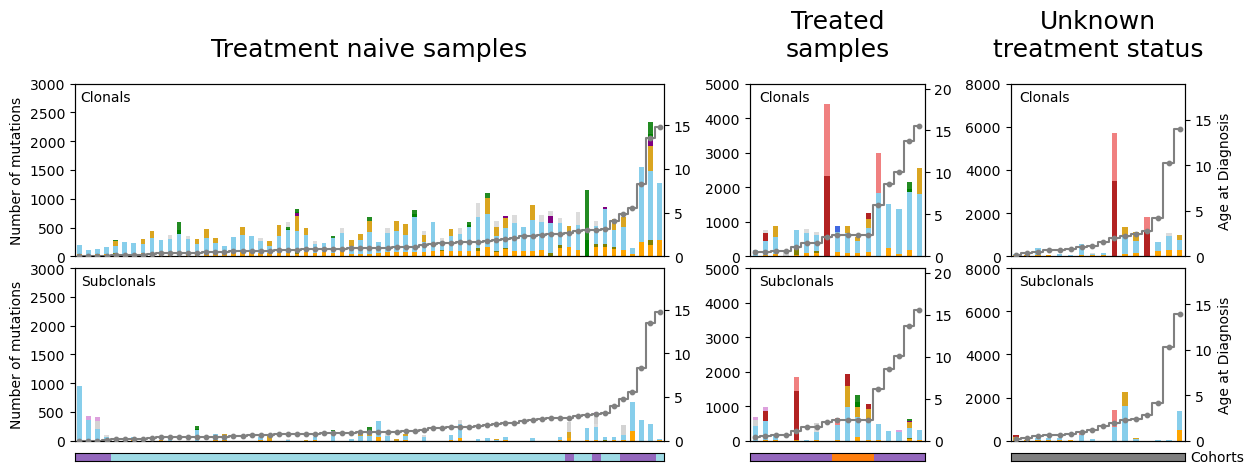

In [30]:
fig = plt.figure(figsize=(16,5), dpi=100)
gs = gridspec.GridSpec(3, 4, height_ratios=[4,4,0.2], width_ratios=[13.5,4,4,1], hspace=0.1, wspace=0.35)

# Function to add the age layer
def add_age_track(ax, df, color='black'):
    # Create a twin axis that shares the same x-axis
    ax_age = ax.twinx()
    
    # Plot age. Using a step or line plot. 
    # 'where=mid' helps align with the center of the bars
    ax_age.step(range(len(df)), df['age'], color=color, where='mid', linewidth=1.5)
    
    # Optional: Add points to make specific sample ages clearer
    ax_age.scatter(range(len(df)), df['age'], color=color, s=10, zorder=3)
    
    # Set labels and limits
    ax_age.set_ylim(0, df['age'].max() + 5) # Buffer for visibility
    return ax_age

n=0
for df in [clonals_df,subclonals_df]:
    ax0 = fig.add_subplot(gs[n,0])

    col_sigs = [col for col in df.columns if 'SBS' in col]
    colors_dict,colors_list = color_sigs(col_sigs)
    df1 = df[df['ttmt'].isin(['naive'])]
    df1[col_sigs].plot.bar(ax=ax0,stacked=True,color=colors_list,legend=False)
    if n==0:
        ax0.set_title('Treatment naive samples',size=18,pad=20)
        ax0.text(x=0.01,y=0.9,s='Clonals',transform = ax0.transAxes)
    else:
        ax0.text(x=0.01,y=0.9,s='Subclonals',transform = ax0.transAxes)
    ax0.set_ylim([0,3000])
    ax0.set_xlabel('')
    ax0.set_xticks([])
    ax0.set_ylabel('Number of mutations')

    ax1 = fig.add_subplot(gs[n,1])

    df2 = df[~df['ttmt'].isin(['naive','NA'])]
    df2[col_sigs].plot.bar(ax=ax1,stacked=True,color=colors_list,legend=False)
    if n==0:
        ax1.set_title('Treated\nsamples',size=18,pad=20)
        ax1.text(x=0.05,y=0.9,s='Clonals',transform = ax1.transAxes)
    else:
        ax1.text(x=0.05,y=0.9,s='Subclonals',transform = ax1.transAxes)
    ax1.set_ylim([0,5000])
    ax1.set_xlabel('')
    ax1.set_xticks([])

    ax2 = fig.add_subplot(gs[n,2])

    df3 = df[df['ttmt'].isin(['NA'])]
    df3[col_sigs].plot.bar(ax=ax2,stacked=True,color=colors_list,legend=False)
    if n==0:
        ax2.set_title('Unknown\ntreatment status',size=18,pad=20)
        ax2.text(x=0.05,y=0.9,s='Clonals',transform = ax2.transAxes)
    else:
        ax2.text(x=0.05,y=0.9,s='Subclonals',transform = ax2.transAxes)
    ax2.set_ylim([0,8000])
    ax2.set_xlabel('')
    ax2.set_xticks([])
    
    n = n+1
    
    # Apply to your subplots
    ax0_age = add_age_track(ax0, df1, color='grey')
    ax1_age = add_age_track(ax1, df2, color='grey')
    ax2_age = add_age_track(ax2, df3, color='grey')
    ax2_age.set_ylabel('Age at Diagnosis') # Only label the first or last one to save space

# --- Heatmap ---

# 1. Setup Global Mapping
# all_cohorts = ['SJD','PMC','StJude','TARGET']
all_cohorts = sorted(allmuts_df['COHORT'].unique().tolist())
cohort_to_idx = {name: i for i, name in enumerate(all_cohorts)}
n_cohorts = len(all_cohorts)

# Get the specific colormap
colormap_dict = {'COHORT': 'tab20'}
feature_colormaps = {}
n_cats = len(all_cohorts)
cmap_name = colormap_dict.get('COHORT', 'Spectral')
cmap = plt.get_cmap(cmap_name)
colors = cmap(np.linspace(0.1, 1, n_cats))
feature_colormaps['COHORT'] = ListedColormap(colors)
current_cmap = feature_colormaps['COHORT']

# 2. Define the NORM once (remove the redundant/broken one inside the loop)
boundaries = np.arange(n_cohorts + 1) - 0.5
norm = mcolors.BoundaryNorm(boundaries=boundaries, ncolors=n_cohorts)

n=0
for df in [df1,df2,df3]:
    ax01 = fig.add_subplot(gs[2,n])

    data = df['COHORT'].map(cohort_to_idx).values

    # Plot the column as an individual image on the same axes
    im = ax01.imshow(data[np.newaxis, :], aspect='auto', cmap=current_cmap, norm=norm)#,
                    # extent=[0, n_rows, n_cols - 1 - i, n_cols - i],
                    # origin='upper')
    n=n+1
    
    # Cleaning up axes
    ax01.set_xticks([])
    ax01.set_yticks([])
    
ax01.text(x=len(data),y=0,s='Cohorts',va='center')
plt.savefig('plots/mutational_signaturs_allsamples_clonal_subclonal.svg', bbox_inches='tight',format='svg')

## Plot only aging sigs from non-treated samples

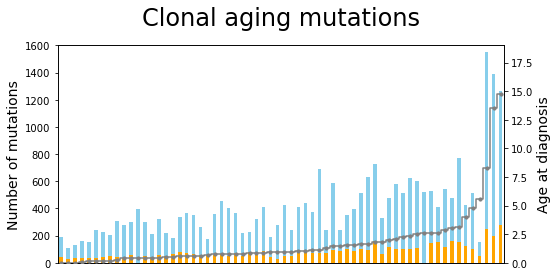

In [31]:
col_sigs = ['SBS1','SBS5']
excluded_samples = ['PADYZI']
df1 = clonals_df[(~clonals_df.index.isin(excluded_samples))&(clonals_df['ttmt']=='naive')]
df1['total'] = df1[col_sigs].sum(axis=1)
df1['age'] = df1.index.map(tab_dict)
df1 = df1.sort_values('age',ascending=True)
df1 = df1.drop(['total'],axis=1)
aging_df = df1[col_sigs+['ttmt']]
age_df = df1[['age']]

colors_dict,colors_list = color_sigs(col_sigs)
ax = aging_df.plot.bar(stacked=True,figsize=(8,4),color=colors_list,legend=False)
# plt.legend(title='Signatures', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Clonal aging mutations',size=24,pad=20)
plt.ylim([0,1600])
plt.xlabel('')
plt.ylabel('Number of mutations',size=14)
plt.xticks([])

# Create a twin axis that shares the same x-axis
ax_age = ax.twinx()

# Plot age. Using a step or line plot. 
# 'where=mid' helps align with the center of the bars
ax_age.step(range(len(age_df)), age_df['age'], color='grey', where='mid', linewidth=1.5)

# Optional: Add points to make specific sample ages clearer
ax_age.scatter(range(len(age_df)), age_df['age'], color='grey', s=10, zorder=3)

# Set labels and limits
ax_age.set_ylim(0, df['age'].max() + 5) # Buffer for visibility

ax_age.set_ylabel('Age at diagnosis',size=14)

plt.savefig('plots/aging_signatures_nontreated_clonal.svg', bbox_inches='tight',format='svg')
plt.show()

In [32]:
print(len(aging_df))
display(aging_df)

64


,SBS1,SBS5,ttmt
Samples,,,
pt18_t1,45.0,144,naive
pt18_t2,25.0,81,naive
pt4_t1,34.0,94,naive
pt4_t2,34.0,124,naive
PAUDPV,33.0,117,naive
...,...,...,...
pt3_t1,103.0,409,naive
pt11_t1,48.0,104,naive
pt1_t1,246.0,1305,naive


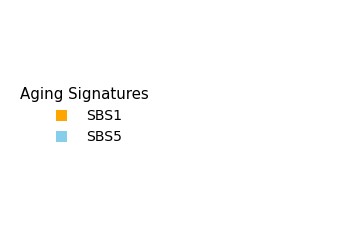

In [34]:
sigs = categories_dict['Aging']
n_cats = len(sigs)
labels = sigs
colors_list = [colors_dict[sig] for sig in sigs]
handles = [plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=colors_list[j], markersize=12) for j in range(n_cats)]
plt.axis('off')
legend_title = 'Aging Signatures'
plt.legend(handles, labels, title=legend_title, loc='center left', ncol=1, fontsize=14, title_fontsize=15, frameon=False)
plt.savefig('plots/aging_signatures_legend.svg', bbox_inches='tight',format='svg')

In [35]:
mappable_counts = json.load(open('mappable_genome/hg38_mappable_genome.trinucleotide_counts.json','rb'))
mappable_length = 0
counts_list = [ mappable_counts[triplet] for triplet in mappable_counts.keys()]
mappable_length = sum(counts_list)
mappable_length

2544920035

In [36]:
col_sigs = [c for c in clonals_df.columns if 'SBS' in c]
clonals_df['total'] = clonals_df[col_sigs].sum(axis=1)
clonals_df['aging'] = clonals_df['SBS1'] + clonals_df['SBS5']
clonals_df['aging_per_mb'] = clonals_df['aging'] / mappable_length * 1000000
clonals_df['SBS1_per_mb'] = clonals_df['SBS1'] / mappable_length * 1000000
clonals_df['SBS5_per_mb'] = clonals_df['SBS5'] / mappable_length * 1000000

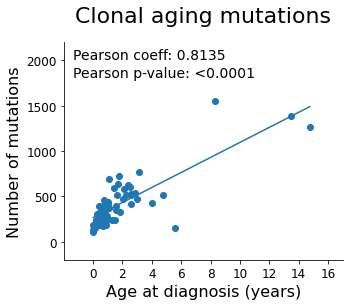

In [37]:
double_germline = ['PADYZI']
treated_samples = {s for s in ttmt2_dict.keys() if ttmt2_dict[s]!='naive'}
excluded_samples = list(treated_samples) + double_germline
df1 = clonals_df[~clonals_df.index.isin(excluded_samples)]

c = '#1f77b4'

plt.figure(figsize=(5,4))
x = df1['age']
y = df1['aging']
plt.scatter(x=x,y=y,c=c)
b, m = polyfit(x, y, 1)
plt.plot(x, b + m * x, '-')

pearson_coef_pval = stats.pearsonr(x=x,y=y)
pearson_coef = round(pearson_coef_pval[0],4)
pearson_pval = round(pearson_coef_pval[1],4)

if pearson_pval == 0:
	pearson_pval = '<0.0001'

plt.text(x=0.15,y=0.82,s='Pearson coeff: '+str(pearson_coef),size=14,transform=plt.gcf().transFigure)
plt.text(x=0.15,y=0.76,s='Pearson p-value: '+str(pearson_pval),size=14,transform=plt.gcf().transFigure)

plt.xlim(-2,17)
plt.ylim(-200,2200)
plt.xticks(range(0,17,2),size=12)
plt.yticks(range(0,2001,500),size=12)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

title = 'Clonal aging mutations'
plt.title(title,size=22,pad=20)
plt.ylabel('Number of mutations',size=16)
plt.xlabel('Age at diagnosis (years)',size=16)
plt.savefig('plots/correlation_clonal_aging_muts_age_diagnosis.svg', bbox_inches='tight',format='svg')
plt.show()

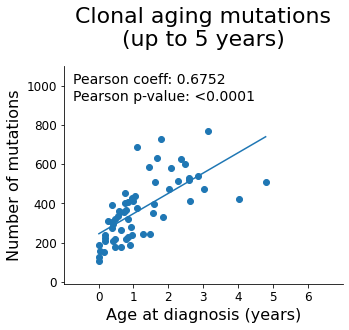

In [38]:
double_germline = ['PADYZI']
treated_samples = {s for s in ttmt2_dict.keys() if ttmt2_dict[s]!='naive'}
excluded_samples = list(treated_samples) + double_germline
df1 = clonals_df[~clonals_df.index.isin(excluded_samples)]

df1 = df1[df1['age']<5]

c = '#1f77b4'

plt.figure(figsize=(5,4))
x = df1['age']
y = df1['aging']
plt.scatter(x=x,y=y,c=c)
b, m = polyfit(x, y, 1)
plt.plot(x, b + m * x, '-')

pearson_coef_pval = stats.pearsonr(x=x,y=y)
pearson_coef = round(pearson_coef_pval[0],4)
pearson_pval = round(pearson_coef_pval[1],4)

if pearson_pval == 0:
	pearson_pval = '<0.0001'

plt.text(x=0.15,y=0.82,s='Pearson coeff: '+str(pearson_coef),size=14,transform=plt.gcf().transFigure)
plt.text(x=0.15,y=0.76,s='Pearson p-value: '+str(pearson_pval),size=14,transform=plt.gcf().transFigure)

plt.xlim(-1,7)
plt.ylim(-10,1100)
plt.xticks(range(0,7,1),size=12)
plt.yticks(range(0,1001,200),size=12)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

title = 'Clonal aging mutations\n(up to 5 years)'
plt.title(title,size=22,pad=20)
plt.ylabel('Number of mutations',size=16)
plt.xlabel('Age at diagnosis (years)',size=16)
plt.savefig('plots/correlation_clonal_aging_muts_age_diagnosis_closeup.svg', bbox_inches='tight',format='svg')
plt.show()